# 模块十四 · 语音处理与大语言模型
## 14.3 综合实践与竞赛模拟（第5-6课时）

> **学习目标**：掌握完整ML项目流程，回顾NOAI全模块考点，练习竞赛策略与模拟题。

---

### 本节内容
1. 完整ML项目流程
2. 端到端实践：贷款预测项目
3. NOAI考点回顾
4. 竞赛策略
5. 模拟练习题

---
# 一、完整ML项目流程

## 1.1 标准流程八步骤

```
① 问题定义 → ② 数据收集 → ③ 数据探索(EDA) → ④ 数据预处理
     ↓
⑤ 特征工程 → ⑥ 模型选择与训练 → ⑦ 模型评估 → ⑧ 部署与监控
```

### 各步骤详解

| 步骤 | 关键活动 | 工具/方法 |
|------|----------|----------|
| **① 问题定义** | 明确任务类型（分类/回归/聚类）、评估指标、业务目标 | 确定输入/输出 |
| **② 数据收集** | 获取数据集、API、爬虫、公开数据 | Kaggle, UCI, 自建数据集 |
| **③ 数据探索** | 统计分析、可视化、发现数据质量问题 | pandas, matplotlib, seaborn |
| **④ 数据预处理** | 处理缺失值、异常值、数据类型转换、标准化/归一化 | sklearn.preprocessing |
| **⑤ 特征工程** | 特征选择、特征构造、降维 | PCA, 特征重要性, 域知识 |
| **⑥ 模型训练** | 选择算法、交叉验证、超参数调优 | sklearn, XGBoost, GridSearchCV |
| **⑦ 模型评估** | 在测试集上评估，选择最佳模型 | 准确率/AUC/RMSE等 |
| **⑧ 部署监控** | 模型服务化、性能监控、定期更新 | Flask, Docker, 模型漂移检测 |

## 1.2 数据预处理要点

### 缺失值处理

| 方法 | 适用场景 |
|------|----------|
| 删除（行/列） | 缺失比例 > 30% |
| 均值/中位数/众数填充 | 数值型/分类型 |
| 插值法（线性/多项式） | 时间序列 |
| 模型预测填充 | 缺失模式有规律 |

### 标准化 vs 归一化

**标准化 (StandardScaler)**：
$$z = \frac{x - \mu}{\sigma}$$
- 均值为0，标准差为1
- 适用于大多数ML算法，特别是假设数据为正态分布的算法

**归一化 (MinMaxScaler)**：
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$
- 缩放到 [0, 1]
- 适用于神经网络、图像像素值

## 1.3 交叉验证 (Cross-Validation)

**K折交叉验证**：将数据分成K份，轮流用K-1份训练，1份验证。

$$CV_{\text{score}} = \frac{1}{K}\sum_{i=1}^{K} \text{Score}_i$$

- K=5 或 K=10 最常用
- 比单次训练-测试划分更可靠
- **分层K折 (Stratified K-Fold)**：保持各类别比例一致（分类任务首选）

## 1.4 常见评估指标

### 分类任务

| 指标 | 公式 | 适用场景 |
|------|------|----------|
| 准确率 (Accuracy) | $\frac{TP+TN}{TP+TN+FP+FN}$ | 类别均衡 |
| 精确率 (Precision) | $\frac{TP}{TP+FP}$ | 关注误报成本 |
| 召回率 (Recall) | $\frac{TP}{TP+FN}$ | 关注漏报成本 |
| F1-Score | $\frac{2PR}{P+R}$ | 精确率和召回率的调和平均 |
| AUC-ROC | — | 类别不均衡，阈值无关 |

### 回归任务

| 指标 | 公式 | 说明 |
|------|------|------|
| MSE | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | 均方误差，对异常值敏感 |
| RMSE | $\sqrt{MSE}$ | 与目标值同量纲 |
| MAE | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | 平均绝对误差，更鲁棒 |
| $R^2$ | $1 - \frac{SS_{res}}{SS_{tot}}$ | 决定系数，越接近1越好 |

---
# 二、端到端实践：贷款预测项目

## 2.1 问题描述

**任务**：根据用户的个人信息（年龄、收入、学历、信用评分等），预测其贷款申请是否会被批准。

- **任务类型**：二分类
- **输入特征**：数值型 + 分类型
- **输出**：0（拒绝）/ 1（批准）
- **评估指标**：F1-Score, AUC-ROC

## 2.2 数据生成与探索

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, f1_score, accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
plt.rcParams['font.family'] = ['SimHei']  # 使用黑体以支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

np.random.seed(42)

# ===== 生成模拟数据集 =====
n_samples = 1000

data = {
    'age': np.random.randint(18, 65, n_samples).astype(float),
    'income': np.random.exponential(50, n_samples) + 10,
    'credit_score': np.random.normal(640, 150, n_samples),
    'education': np.random.choice(['高中', '本科', '硕士', '博士'], n_samples, 
                                   p=[0.3, 0.4, 0.2, 0.1]),
    'employment_years': np.random.randint(0, 20, n_samples),
    'loan_amount': np.random.exponential(150, n_samples) + 10,
    'existing_debt': np.random.exponential(25, n_samples),
}

# 生成标签（基于规则 + 噪声）
# 修正 education 的 isin 用法
is_masters_or_phd = np.isin(data['education'], ['硕士', '博士'])
score = (
    0.3 * (data['income'] / 100) +
    0.2 * (data['credit_score'] / 850) +
    0.1 * (data['employment_years'] / 20) -
    0.2 * (data['existing_debt'] / 100) -
    0.1 * (data['loan_amount'] / 300) +
    0.1 * np.where(is_masters_or_phd, 1, 0)
)
noise = np.random.normal(0, 0.15, n_samples)
data['approved'] = (score + noise > 0.45).astype(int)

# 添加缺失值
for col in ['age', 'income', 'credit_score', 'loan_amount', 'existing_debt']:
    mask = np.random.random(n_samples) < 0.01
    data[col] = np.where(mask, np.nan, data[col])

df = pd.DataFrame(data)
df['credit_score'] = df['credit_score'].clip(300, 850)

print(f"数据集形状: {df.shape}")
print(f"\n数据类型:")
print(df.dtypes)
print(f"\n缺失值:")
print(df.isnull().sum())
print(f"\n目标变量分布:")
print(df['approved'].value_counts().to_string())
pct = df['approved'].value_counts(normalize=True)
print(f"  数据类别{'' if abs(pct[0]-0.5)<0.1 else '不'}均衡。")
print(f"\n数值特征统计:")
print(df.describe().round(3))

数据集形状: (1000, 8)

数据类型:
age                 float64
income              float64
credit_score        float64
education            object
employment_years      int32
loan_amount         float64
existing_debt       float64
approved              int32
dtype: object

缺失值:
age                 15
income               9
credit_score        11
education            0
employment_years     0
loan_amount          4
existing_debt       10
approved             0
dtype: int64

目标变量分布:
approved
0    745
1    255
  数据类别不均衡。

数值特征统计:
           age   income  credit_score  employment_years  loan_amount  \
count  985.000  991.000       989.000          1000.000      996.000   
mean    40.968   61.011       640.815             9.852      154.820   
std     13.496   50.564       136.377             5.763      145.182   
min     18.000   10.232       300.000             0.000       10.312   
25%     29.000   23.622       548.134             5.000       53.224   
50%     42.000   46.578       642.827          

## 2.3 数据可视化

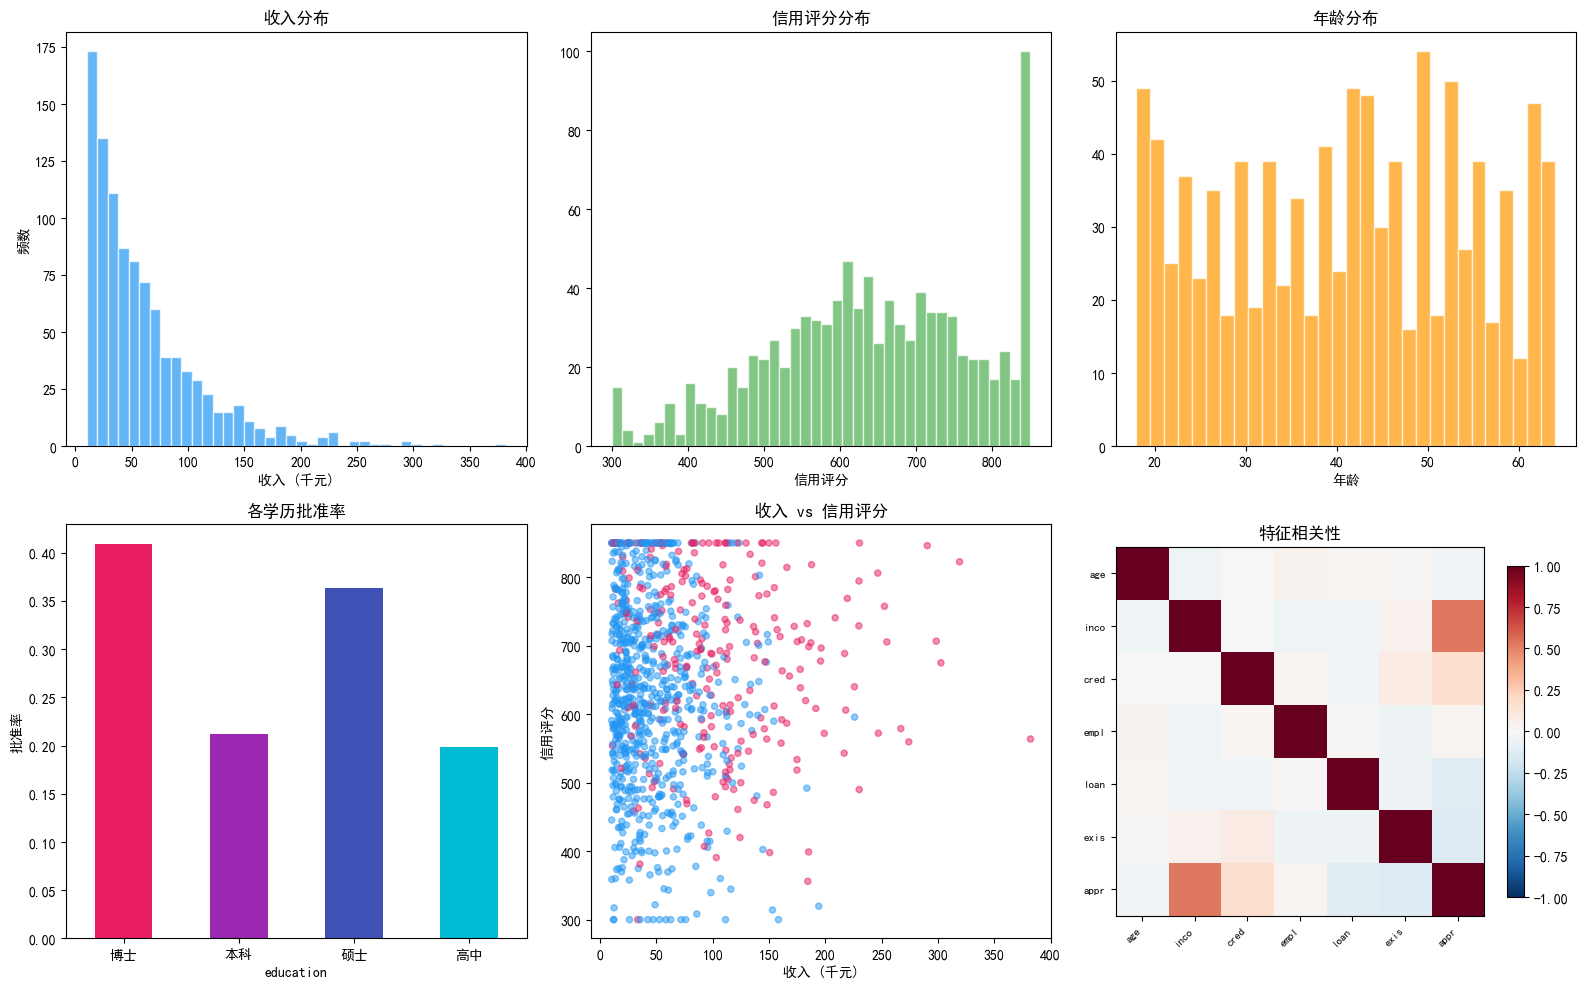

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 收入分布
axes[0, 0].hist(df['income'].dropna(), bins=40, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0, 0].set_title('收入分布', fontsize=12)
axes[0, 0].set_xlabel('收入 (千元)')
axes[0, 0].set_ylabel('频数')

# 信用评分分布
axes[0, 1].hist(df['credit_score'].dropna(), bins=40, color='#4CAF50', alpha=0.7, edgecolor='white')
axes[0, 1].set_title('信用评分分布', fontsize=12)
axes[0, 1].set_xlabel('信用评分')

# 年龄分布
axes[0, 2].hist(df['age'].dropna(), bins=30, color='#FF9800', alpha=0.7, edgecolor='white')
axes[0, 2].set_title('年龄分布', fontsize=12)
axes[0, 2].set_xlabel('年龄')

# 教育水平与批准率
edu_approval = df.groupby('education')['approved'].mean()
edu_approval.plot(kind='bar', ax=axes[1, 0], color=['#E91E63', '#9C27B0', '#3F51B5', '#00BCD4'])
axes[1, 0].set_title('各学历批准率', fontsize=12)
axes[1, 0].set_ylabel('批准率')
axes[1, 0].tick_params(axis='x', rotation=0)

# 收入 vs 信用评分散点图
colors = ['#E91E63' if a == 1 else '#2196F3' for a in df['approved']]
axes[1, 1].scatter(df['income'], df['credit_score'], c=colors, alpha=0.5, s=20)
axes[1, 1].set_title('收入 vs 信用评分', fontsize=12)
axes[1, 1].set_xlabel('收入 (千元)')
axes[1, 1].set_ylabel('信用评分')

# 特征相关性热力图
numeric_cols = ['age', 'income', 'credit_score', 'employment_years', 
                'loan_amount', 'existing_debt', 'approved']
corr = df[numeric_cols].corr()
im = axes[1, 2].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1, 2].set_title('特征相关性', fontsize=12)
axes[1, 2].set_xticks(range(len(numeric_cols)))
axes[1, 2].set_yticks(range(len(numeric_cols)))
axes[1, 2].set_xticklabels([c[:4] for c in numeric_cols], rotation=45, ha='right', fontsize=8)
axes[1, 2].set_yticklabels([c[:4] for c in numeric_cols], fontsize=8)
plt.colorbar(im, ax=axes[1, 2], shrink=0.8)

plt.tight_layout()
plt.show()

## 2.4 数据预处理

In [13]:
# ===== 步骤1: 分离特征和标签 =====
print("===== 步骤1: 分离特征和标签 =====")
X = df.drop('approved', axis=1)
y = df['approved']
print(f"X 形状: {X.shape}")
print(f"y 形状: {y.shape}")

# ===== 步骤2: 编码分类变量 =====
print("\n===== 步骤2: 编码分类变量 =====")
le = LabelEncoder()
X['education'] = le.fit_transform(X['education'])
print(f"education 编码: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ===== 步骤3: 处理缺失值 =====
print("\n===== 步骤3: 处理缺失值 =====")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f"填补后缺失值总数: {X_imputed.isnull().sum().sum()}")

# ===== 步骤4: 数据划分 =====
print("\n===== 步骤4: 数据划分 =====")
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {len(X_train)} 样本")
print(f"测试集: {len(X_test)} 样本")

# ===== 步骤5: 特征标准化 =====
print("\n===== 步骤5: 特征标准化 =====")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"标准化完成，特征维度: {X_train_scaled.shape}")
print(f"均值: {np.mean(X_train_scaled, axis=0).round(2).tolist()}")
print(f"标准差: {np.std(X_train_scaled, axis=0).round(2).tolist()}")

===== 步骤1: 分离特征和标签 =====
X 形状: (1000, 7)
y 形状: (1000,)

===== 步骤2: 编码分类变量 =====
education 编码: {'博士': 0, '本科': 1, '硕士': 2, '高中': 3}

===== 步骤3: 处理缺失值 =====
填补后缺失值总数: 0

===== 步骤4: 数据划分 =====
训练集: 800 样本
测试集: 200 样本

===== 步骤5: 特征标准化 =====
标准化完成，特征维度: (800, 7)
均值: [-0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0]
标准差: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## 2.5 模型训练与对比

In [14]:
# ===== 定义多个模型 =====
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=4, 
                                                      learning_rate=0.1, random_state=42),
}

# ===== 5折交叉验证 =====
print("===== 模型训练与5折交叉验证 =====")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_model_name = None
best_cv_score = 0

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    print(f"\n{name}:")
    print(f"   交叉验证 F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    if cv_scores.mean() > best_cv_score:
        best_cv_score = cv_scores.mean()
        best_model_name = name

# ===== 在测试集上评估最佳模型 =====
print(f"\n===== 测试集评估 =====")
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"最佳模型: {best_model_name}")
print(f"准确率: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")

===== 模型训练与5折交叉验证 =====

Logistic Regression:
   交叉验证 F1: 0.6201 ± 0.0352

Decision Tree:
   交叉验证 F1: 0.5373 ± 0.0302

Random Forest:
   交叉验证 F1: 0.5910 ± 0.0482

Gradient Boosting:
   交叉验证 F1: 0.6006 ± 0.0584

===== 测试集评估 =====
最佳模型: Logistic Regression
准确率: 0.8400
F1-Score: 0.6522
AUC-ROC: 0.8895


## 2.6 详细评估结果

In [15]:
# ===== 分类报告 =====
print("===== 分类报告 =====")
print(classification_report(y_test, y_pred, target_names=['拒绝(0)', '批准(1)']))

# ===== 混淆矩阵 =====
print("===== 混淆矩阵 =====")
cm = confusion_matrix(y_test, y_pred)
print("预测拒绝(0)  预测批准(1)")
for i, row in enumerate(cm):
    label = "← 实际拒绝" if i == 0 else "← 实际批准"
    print(f"  [{row[0]:3d}, {row[1]:3d}]    {label}")

# ===== 特征重要性 =====
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_names = X.columns.tolist()
    feat_imp = sorted(zip(feat_names, importances), key=lambda x: x[1], reverse=True)
    print("\n特征重要性排序:")
    for rank, (name, imp) in enumerate(feat_imp, 1):
        print(f"  {rank}. {name:16s}: {imp:.4f}")

===== 分类报告 =====
              precision    recall  f1-score   support

       拒绝(0)       0.87      0.93      0.90       149
       批准(1)       0.73      0.59      0.65        51

    accuracy                           0.84       200
   macro avg       0.80      0.76      0.77       200
weighted avg       0.83      0.84      0.83       200

===== 混淆矩阵 =====
预测拒绝(0)  预测批准(1)
  [138,  11]    ← 实际拒绝
  [ 21,  30]    ← 实际批准


## 2.7 可视化评估结果

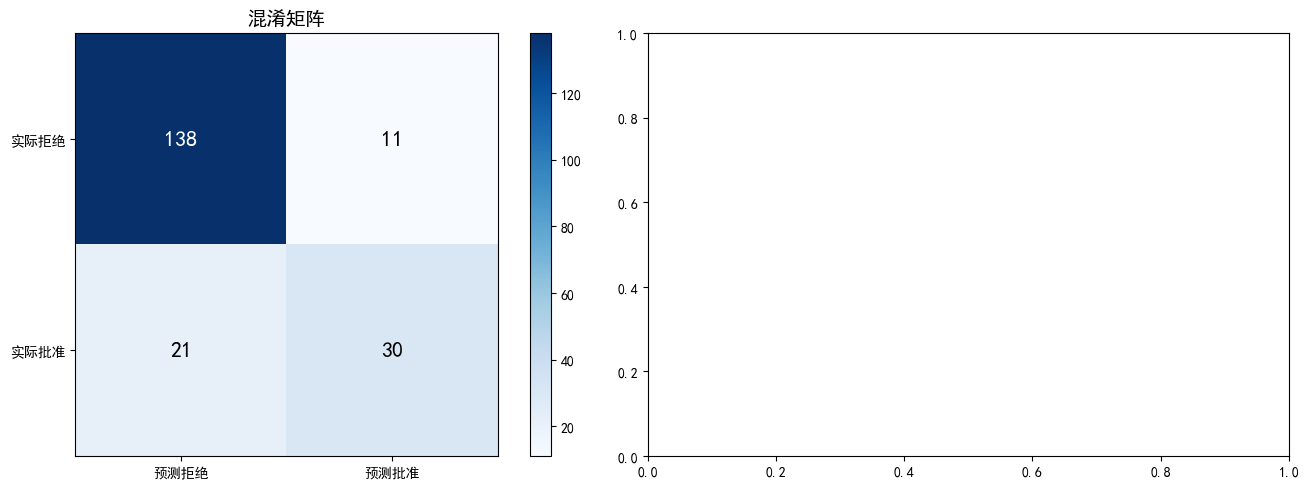

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 混淆矩阵热力图
im = ax1.imshow(cm, cmap='Blues')
ax1.set_title('混淆矩阵', fontsize=14)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['预测拒绝', '预测批准'])
ax1.set_yticklabels(['实际拒绝', '实际批准'])
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        ax1.text(j, i, str(cm[i, j]), ha='center', va='center', 
                fontsize=16, fontweight='bold', color=color)
plt.colorbar(im, ax=ax1)

# 特征重要性
if hasattr(best_model, 'feature_importances_'):
    feat_names = X.columns.tolist()
    importances = best_model.feature_importances_
    sorted_idx = np.argsort(importances)
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importances)))
    ax2.barh(range(len(importances)), importances[sorted_idx], color=colors[sorted_idx])
    ax2.set_yticks(range(len(importances)))
    ax2.set_yticklabels([feat_names[i] for i in sorted_idx])
    ax2.set_title('特征重要性', fontsize=14)
    ax2.set_xlabel('重要性得分')

plt.tight_layout()
plt.show()

---
# 三、NOAI 全模块考点回顾

## 3.1 A/B/C/D 四大区域速查表

| 区域 | 模块 | 核心知识点 |
|------|------|----------|
| **A: 数据基础** | 模块1-2 | 数据类型、Python基础、NumPy、Pandas、数据清洗、可视化 |
| **B: 机器学习** | 模块3-6 | 监督/无监督学习、回归/分类/聚类、决策树、SVM、KNN、集成学习、特征工程 |
| **C: 深度学习** | 模块7-11 | 神经网络基础、CNN、RNN/LSTM、Transformer、NLP、计算机视觉、强化学习 |
| **D: 前沿应用** | 模块12-14 | 语音处理(ASR/TTS)、生成式AI/LLM、多模态AI、综合实践 |

## 3.2 高频考点总结

### 🔢 数学基础

| 考点 | 公式/概念 |
|------|----------|
| 概率基础 | 贝叶斯定理: $P(A|B) = \frac{P(B|A)P(A)}{P(B)}$ |
| 信息论 | 熵: $H(X) = -\sum p(x)\log_2 p(x)$，交叉熵 |
| 导数与梯度 | 链式法则，梯度下降: $\theta = \theta - \eta\nabla L$ |
| 矩阵运算 | 点积、矩阵乘法、转置 |

### 📊 机器学习核心

| 考点 | 关键词 |
|------|--------|
| 欠拟合 vs 过拟合 | 偏差-方差权衡，正则化 L1/L2 |
| 损失函数 | MSE、交叉熵 $-\sum y\log\hat{y}$、SVM hinge loss |
| 决策树 | 信息增益、基尼系数、剪枝 |
| 集成学习 | Bagging(RF) vs Boosting(XGBoost/GBDT) |
| 交叉验证 | K折、分层K折 |
| 评估指标 | Accuracy/Precision/Recall/F1/AUC/RMSE |

### 🧠 深度学习核心

| 考点 | 关键词 |
|------|--------|
| 激活函数 | ReLU $\max(0,x)$、Sigmoid、Tanh、Softmax |
| 反向传播 | 链式法则，梯度消失/爆炸 |
| CNN | 卷积核、池化、感受野、LeNet/AlexNet/VGG/ResNet |
| RNN/LSTM | 长短期记忆、遗忘门/输入门/输出门 |
| Transformer | Self-Attention $\text{softmax}(QK^T/\sqrt{d_k})V$ |
| 优化器 | SGD→Adam: $m_t, v_t$ 的动量+自适应学习率 |
| 正则化 | Dropout、Batch Norm、数据增强、Early Stopping |

### 🤖 前沿应用

| 考点 | 关键词 |
|------|--------|
| 语音处理 | 奈奎斯特定理、MFCC 7步、STFT参数 |
| ASR | GMM-HMM、CTC损失(blank token)、Whisper |
| LLM | 自回归生成、Temperature/Top-k/Top-p、CoT |
| 多模态 | CLIP图文对比学习、Stable Diffusion扩散模型 |
| 幻觉与RAG | 产生原因、缓解方法、检索增强生成 |

---
# 四、竞赛策略

## 4.1 答题优先级

```
第一轮（确保基础分）:
  ✅ 选择题 → 先做确定的，标记不确定的
  ✅ 计算题 → 按公式一步步算，注意单位

第二轮（争取中高分）:
  ✅ 标记的选择题 → 消除法
  ✅ 简答题 → 写出关键点，不纠结细节

第三轮（冲击高分）:
  ✅ 代码阅读/填空 → 理解代码逻辑
  ✅ 综合分析题 → 结合多个知识点
```

## 4.2 时间分配建议

| 题型 | 时间占比 | 策略 |
|------|---------|------|
| 选择题 | 25% | 每题1-2分钟，不确定先跳过 |
| 计算题 | 30% | 列出公式→代入数值→算结果 |
| 简答题 | 25% | 列要点，画图辅助 |
| 代码题 | 15% | 读懂代码→追踪变量→推算输出 |
| 检查 | 5% | 检查单位、公式、计算 |

## 4.3 易错点

### ⚠️ 常见错误

1. **公式记混**：Softmax vs Sigmoid vs Softmax+Temperature
2. **单位/参数错误**：采样率44.1kHz（不是44.1MHz），帧长25ms（不是25s）
3. **概念混淆**：
   - Precision vs Recall（FP vs FN）
   - Bagging vs Boosting（并行 vs 串行）
   - GPT vs BERT（Decoder-only vs Encoder-only）
   - MFCC vs Mel Spectrogram（做了DCT vs 没做DCT）
4. **代码阅读**：注意索引从0开始、数组维度、广播机制
5. **计算粗心**：log 是 ln 还是 log₁₀，注意底数

### 💡 实用技巧

- **选择题排除法**：先排除明显错误的选项
- **计算题验算**：结果数量级合理吗？
- **代码题手动追踪**：用表格记录每步变量值
- **不确定的题**：相信第一直觉，不要反复改

---
# 五、模拟练习题

## 5.1 选择题

**Q1.【A区】** Pandas 中 `df.groupby('col').mean()` 的作用是什么？
- A. 对整个DataFrame求均值
- B. 按列 'col' 分组后对每组求均值  ✅
- C. 按列 'col' 排序
- D. 计算列 'col' 的均值

**Q2.【B区】** 决策树中，信息增益的计算基于？
- A. 方差减小量
- B. 熵的减小量  ✅
- C. 误差率
- D. 准确率提升

**Q3.【B区】** 随机森林使用 Bagging 策略，其核心特点是？
- A. 基学习器按顺序训练
- B. 基学习器独立并行训练，结合随机特征子集  ✅
- C. 只使用一个基学习器
- D. 使用梯度下降优化

**Q4.【C区】** ReLU 激活函数的表达式是？
- A. $\sigma(x) = \frac{1}{1+e^{-x}}$
- B. $f(x) = \max(0, x)$  ✅
- C. $f(x) = \tanh(x)$
- D. $f(x) = x^2$

**Q5.【C区】** 在 Transformer 中，多头注意力的主要优势是？
- A. 减少计算量
- B. 让模型关注序列的不同方面  ✅
- C. 减少参数量
- D. 替代位置编码

**Q6.【D区】** 以下关于 MFCC 和 Mel Spectrogram 的说法，正确的是？
- A. MFCC 包含更多信息
- B. Mel Spectrogram 比 MFCC 多做了一步 DCT
- C. MFCC 在 Mel Spectrogram 基础上做了 DCT，压缩为低维特征  ✅
- D. 两者完全相同

**Q7.【D区】** 降低 Temperature 对 LLM 生成的影响是？
- A. 输出更随机
- B. 输出更确定，接近贪心解码  ✅
- C. 不影响输出分布
- D. 增加输出的多样性

## 5.2 计算题

**Q8.【B区】** 一个二分类模型在100个样本上的混淆矩阵为：TP=40, TN=35, FP=10, FN=15。
请计算精确率(Precision)、召回率(Recall)和F1-Score。

> **解**：
> - Precision $= \frac{TP}{TP+FP} = \frac{40}{40+10} = \frac{40}{50} = 0.80$
> - Recall $= \frac{TP}{TP+FN} = \frac{40}{40+15} = \frac{40}{55} \approx 0.727$
> - F1 $= \frac{2 \times P \times R}{P+R} = \frac{2 \times 0.8 \times 0.727}{0.8 + 0.727} = \frac{1.164}{1.527} \approx 0.762$

**Q9.【C区】** 一个两分类的 Softmax 输出 logits = [2.0, 1.0]，求每个类别的概率。

> **解**：$P(1) = \frac{e^{2.0}}{e^{2.0}+e^{1.0}} = \frac{7.389}{7.389+2.718} = \frac{7.389}{10.107} \approx 0.731$

> $P(2) = \frac{e^{1.0}}{e^{2.0}+e^{1.0}} = \frac{2.718}{10.107} \approx 0.269$

## 5.3 代码阅读题

**Q10.** 阅读以下代码，写出输出结果：
```python
import numpy as np
a = np.array([[1, 2], [3, 4]])
b = np.array([10, 20])
print(a + b)  # 第1行输出
print((a * b).sum())  # 第2行输出
```

In [17]:
# Q10 代码运行验证
import numpy as np
a = np.array([[1, 2], [3, 4]])
b = np.array([10, 20])
print(a + b)       # 广播: [[1+10, 2+20], [3+10, 4+20]]
print((a * b).sum())  # 元素乘: [[10,40],[30,80]] → 10+40+30+80=160

print("\n解析:")
print("第1行: NumPy广播机制, b=[10,20]扩展为[[10,20],[10,20]]")
print("  a+b = [[1+10, 2+20], [3+10, 4+20]] = [[11,22],[13,24]]")
print("第2行: 元素乘法 a*b = [[1*10, 2*20], [3*10, 4*20]] = [[10,40],[30,80]]")
print(f"  sum = 10+40+30+80 = {(a*b).sum()}")

[[11 22]
 [13 24]]
160

解析:
第1行: NumPy广播机制, b=[10,20]扩展为[[10,20],[10,20]]
  a+b = [[1+10, 2+20], [3+10, 4+20]] = [[11,22],[13,24]]
第2行: 元素乘法 a*b = [[1*10, 2*20], [3*10, 4*20]] = [[10,40],[30,80]]
  sum = 10+40+30+80 = 160


**Q11.** 阅读以下代码，写出输出结果：
```python
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

logits = np.array([0.0, 2.0, -1.0])
temp = 0.5
scaled = logits / temp
probs = np.exp(scaled - np.max(scaled)) / np.sum(np.exp(scaled - np.max(scaled)))
print(probs.round(3))
print(np.argmax(probs))
```

In [18]:
# Q11 代码运行验证
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

logits = np.array([0.0, 2.0, -1.0])
temp = 0.5
scaled = logits / temp  # [0.0, 4.0, -2.0]
print(f"scaled logits: {scaled}")
probs = np.exp(scaled - np.max(scaled)) / np.sum(np.exp(scaled - np.max(scaled)))
print(probs.round(3))
print(np.argmax(probs))

print("\n解析:")
print("scaled = [0/0.5, 2/0.5, -1/0.5] = [0, 4, -2]")
print("Temperature=0.5 < 1, logits被放大, 分布更尖锐")
print(f"最大值对应索引1(原logits=2.0), 概率={probs[1]:.3f}")

scaled logits: [ 0.  4. -2.]
[0.018 0.98  0.002]
1

解析:
scaled = [0/0.5, 2/0.5, -1/0.5] = [0, 4, -2]
Temperature=0.5 < 1, logits被放大, 分布更尖锐
最大值对应索引1(原logits=2.0), 概率=0.980


## 5.4 综合应用题

**Q12.【综合】** 某公司要构建一个语音客服系统，需要完成以下任务：
(1) 将用户语音转为文字
(2) 理解用户意图
(3) 生成回答文字
(4) 将回答文字转为语音

请为每个任务选择合适的技术方案，并说明理由。

> **参考答案**：
>
| 任务 | 技术方案 | 理由 |
|------|----------|------|
| (1) 语音→文字 | **Whisper** 或 CTC-based ASR | Whisper 多语言、鲁棒性强；CTC 处理对齐 |
| (2) 理解意图 | **LLM (GPT系列)** + Few-Shot Prompt | 理解自然语言，分类意图 |
| (3) 生成回答 | **LLM (GPT系列)** + RAG | 生成自然语言回答，RAG减少幻觉 |
| (4) 文字→语音 | **VITS / TTS模型** | 快速、高质量的语音合成 |

**Q13.【综合】** 训练一个图像分类模型时，发现训练集准确率95%但测试集只有60%，这是什么问题？请列举至少3种缓解方法。

> **参考答案**：这是典型的**过拟合 (Overfitting)** 问题——模型在训练集上学到了训练数据特有的噪声和细节，泛化能力差。
>
> 缓解方法：
> 1. **数据增强**：随机裁剪、翻转、颜色抖动等增加训练数据多样性
> 2. **正则化**：L2正则化（权重衰减）、Dropout随机丢弃神经元
> 3. **Early Stopping**：监控验证集loss，在过拟合前停止训练
> 4. **减少模型复杂度**：减少层数/参数量、使用更小的模型
> 5. **Batch Normalization**：标准化每层输入，起到一定正则化效果
> 6. **集成方法**：多模型投票/平均
> 7. **增加训练数据**：收集更多数据或使用预训练模型微调

---
# 六、课程总结与后续建议

## 6.1 模块十四知识总结

```
模块十四：语音处理与大语言模型
│
├── 14.1 语音信号处理
│   ├── 信号基础：频率/振幅/波形、采样量化、STFT
│   ├── 特征提取：ZCR/能量、频谱、MFCC(7步)、Mel Spectrogram
│   ├── ASR：GMM-HMM → CTC → Whisper
│   └── TTS：拼接 → 神经网络(Tacotron/WaveNet) → 大模型
│
├── 14.2 生成式AI与大语言模型
│   ├── 生成式 vs 判别式：p(x) vs p(y|x)
│   ├── LLM核心：Transformer、自回归、采样策略(T/Top-k/Top-p)
│   ├── Prompt Engineering：Zero/Few-Shot、CoT
│   ├── 幻觉：原因与RAG缓解
│   └── 多模态：CLIP、Stable Diffusion、GPT-4V
│
└── 14.3 综合实践
    ├── 完整ML流程：8步骤
    ├── 端到端项目：贷款预测（数据→预处理→模型→评估）
    └── 竞赛策略：答题优先级、时间分配、易错点
```

## 6.2 NOAI 全课程回顾

| 区域 | 模块 | 知识树 |
|------|------|--------|
| **A** | 1-2 | Python编程 → NumPy/Pandas → 数据清洗与可视化 |
| **B** | 3-6 | 监督学习(回归/分类) → 无监督(聚类/降维) → 集成学习 → 特征工程 |
| **C** | 7-11 | NN基础 → CNN → RNN/LSTM → Transformer → NLP/CV → 强化学习 |
| **D** | 12-14 | 搜索算法 → 语音处理 → 生成式AI/LLM → 综合实践 |

## 6.3 后续学习建议

1. **巩固基础**：复习各模块核心公式和概念，完成所有课后练习
2. **动手实践**：Kaggle 竞赛（Titanic/House Prices 入门），复现代码
3. **拓展阅读**：
   - 《动手学深度学习》(d2l.ai)
   - CS231n (Stanford 计算机视觉课程)
   - CS224n (Stanford NLP 课程)
   - Attention Is All You Need (Transformer原论文)
4. **关注前沿**：关注 AI 领域最新进展（arXiv, Hugging Face, 各大实验室博客）
5. **竞赛准备**：刷历年真题，做限时模拟，总结易错点

---

> 🎉 **恭喜你完成了模块十四的全部课程！**
>
> 祝你在NOAI竞赛中取得优异成绩！加油！💪